[Previous: Start Here](00_Start_Here.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 2: Arrays, Linked Lists, Stacks and Queues](02_Arrays_Linked_Lists_Stacks_Queues.ipynb)

# Module 1: Complexity and Big-O

**Learning objectives.** After this module you can:

* count the steps an algorithm takes and express the count as a function of the input size;
* apply the two rules of Big-O (drop constants, keep the dominant term) and name the common classes;
* confirm a Big-O estimate with a timing plot and read the slope on log axes;
* explain best case, worst case and amortised cost with concrete examples.

**Prerequisites.** Run the environment check in [Start Here](00_Start_Here.ipynb).

## 1. Counting steps

You are looking for a name in a printed phone book with a million entries. Two strategies:

* **Start at page one and read every name.** Up to a million looks.
* **Open the middle, decide left or right, repeat.** Each look throws away half the book: 20 looks.

Both are correct. One is fifty thousand times faster, and the gap *grows* with the size of the book. That growth is what complexity analysis measures.
Below, both strategies are written as functions that count their own steps.

In [1]:
import math, random, sys
import matplotlib.pyplot as plt
from dsalab import time_it, growth_plot, draw_array

def linear_search(items, target):
    steps = 0
    for i, x in enumerate(items):
        steps += 1
        if x == target:
            return i, steps
    return -1, steps

def binary_search(items, target, hi=None):
    lo, hi, steps = 0, (len(items) - 1 if hi is None else hi), 0
    while lo <= hi:
        steps += 1
        mid = (lo + hi) // 2
        if items[mid] == target:
            return mid, steps
        if items[mid] < target:
            lo = mid + 1
        else:
            hi = mid - 1
    return -1, steps

million = list(range(1_000_000))          # sorted, like the phone book
print("linear search for the last item:", linear_search(million, 999_999))
print("binary search for the last item:", binary_search(million, 999_999))
print("binary search for a missing item:", binary_search(million, -5))

linear search for the last item: (999999, 1000000)
binary search for the last item: (999999, 20)
binary search for a missing item: (-1, 19)


In [2]:
# The number of steps as the input grows. Binary search barely moves.
print(f"{'n':>10} {'linear (worst)':>16} {'binary (worst)':>16}")
for n in [10, 100, 1_000, 10_000, 100_000, 1_000_000]:
    items = list(range(n))
    _, lin = linear_search(items, n - 1)
    _, bi = binary_search(items, n - 1)
    print(f"{n:>10,} {lin:>16,} {bi:>16}")

         n   linear (worst)   binary (worst)
        10               10                4
       100              100                7
     1,000            1,000               10
    10,000           10,000               14
   100,000          100,000               17
 1,000,000        1,000,000               20


> **What to notice.** Multiply n by 10 and linear search does 10 times more work, binary search about 3 steps more.
> That is the difference between $O(n)$ and $O(\log n)$, and it is the whole reason sorted data and clever structures exist.

## 2. Big-O: keeping only what matters

Exact step counts depend on the machine, the language and small details. Big-O keeps the part that survives all of that: **how the count grows**.
Two rules turn a step count into a Big-O class:

1. **Drop constant factors.** $3n$ and $n/2$ are both $O(n)$.
2. **Keep only the fastest-growing term.** $n^2 + 50n + 1000$ is $O(n^2)$, because for large $n$ the $n^2$ dwarfs the rest.

The table shows why the class matters more than the constant. The columns are the step counts for each class at growing $n$.

In [3]:
print(f"{'n':>10} {'log n':>8} {'n':>12} {'n log n':>14} {'n^2':>16} {'2^n':>14}")
for n in [10, 100, 1_000, 1_000_000]:
    two = f"{2.0**n:.1e}" if n <= 1_000 else "beyond reason"
    print(f"{n:>10,} {math.log2(n):>8.1f} {n:>12,} {n*math.log2(n):>14,.0f} {n*n:>16,} {two:>14}")

         n    log n            n        n log n              n^2            2^n
        10      3.3           10             33              100        1.0e+03
       100      6.6          100            664           10,000        1.3e+30
     1,000     10.0        1,000          9,966        1,000,000       1.1e+301
 1,000,000     19.9    1,000,000     19,931,569 1,000,000,000,000  beyond reason


## 3. Measure it: timing plots

A Big-O claim is a prediction about a curve, so draw the curve. `growth_plot` times a function at several input sizes and plots on **log-log axes**,
where $O(n^k)$ becomes a straight line of slope $k$. Constant time is flat, logarithmic is almost flat, linear has slope 1, quadratic slope 2.

Five functions, one of each class. The quadratic one gets much smaller inputs, otherwise you would wait all day.

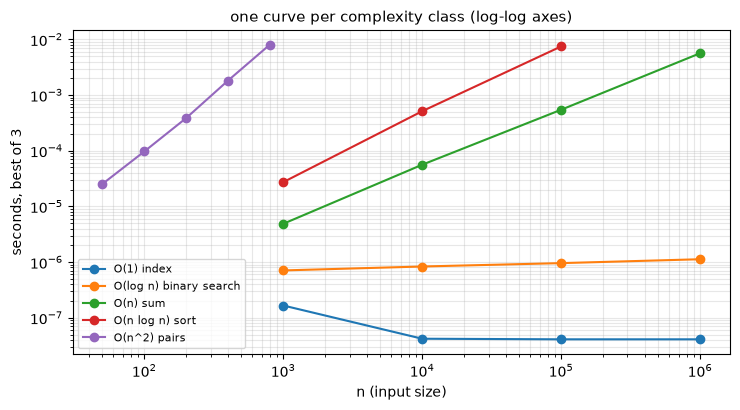

In [4]:
random.seed(1)
shuffled = [random.random() for _ in range(100_000)]

def constant(n):     return million[n - 1]                      # one index operation
def logarithmic(n):  return binary_search(million, n - 1, hi=n - 1)
def linear(n):       return sum(range(n))
def n_log_n(n):      return sorted(shuffled[:n])
def quadratic(n):    return sum(1 for i in range(n) for j in range(n) if i < j)

growth_plot(
    {"O(1) index": constant, "O(log n) binary search": logarithmic, "O(n) sum": linear,
     "O(n log n) sort": n_log_n, "O(n^2) pairs": quadratic},
    {"O(1) index": [10**3, 10**4, 10**5, 10**6], "O(log n) binary search": [10**3, 10**4, 10**5, 10**6],
     "O(n) sum": [10**3, 10**4, 10**5, 10**6], "O(n log n) sort": [10**3, 10**4, 10**5],
     "O(n^2) pairs": [50, 100, 200, 400, 800]},
    title="one curve per complexity class (log-log axes)",
)

> **What to notice.** The quadratic line is the steepest and it reaches a tenth of a second at n = 800, an input a million times smaller
> than what the linear function handles in the same time. Slope is destiny.

## 4. Best, worst and amortised

Linear search for an item at the front takes one step; for a missing item it takes $n$. Big-O usually reports the **worst case**, because that is the promise you can rely on.
Sometimes the interesting number is the **average** (quicksort, hash tables), and sometimes an operation is occasionally slow but cheap *on average over a sequence*.
That last idea is **amortised** cost, and Python's `list.append` is the classic example: most appends are O(1), and once in a while the list grows its storage in O(n),
but the doubling strategy makes the average O(1). The measurement below shows the per-append cost staying flat as n grows.

In [5]:
items = list(range(1000))
print("best case  (target at index 0):  ", linear_search(items, 0)[1], "step")
print("worst case (target missing):     ", linear_search(items, -1)[1], "steps")

def build_by_append(n):
    out = []
    for i in range(n):
        out.append(i)
    return out

print("\nappend cost per element (should stay roughly flat):")
for n in [10**4, 10**5, 10**6]:
    t = time_it(build_by_append, n)
    print(f"  n = {n:>9,}: {t / n * 1e9:6.1f} ns per append")

best case  (target at index 0):   1 step
worst case (target missing):      1000 steps

append cost per element (should stay roughly flat):
  n =    10,000:    9.6 ns per append
  n =   100,000:    9.7 ns per append
  n = 1,000,000:   12.1 ns per append


## 5. Space complexity

The same language applies to memory. Linear search uses O(1) extra space (a couple of variables). Building a list of all n items uses O(n).
Merge sort (Module 4) needs O(n) scratch space; quicksort sorts in place. When two algorithms tie on time, space often decides.

### Lab: Binary Search Stepper

Pick a target and step through the comparisons. Grey cells have been ruled out; the orange cell is the one being compared. Try the missing value too.

Binary Search Stepper (static preview). Run this cell in JupyterLab for the interactive version.


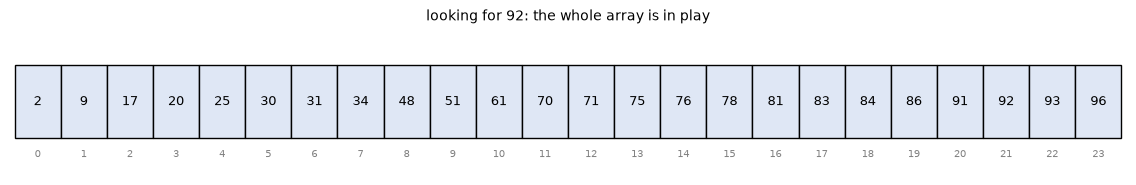

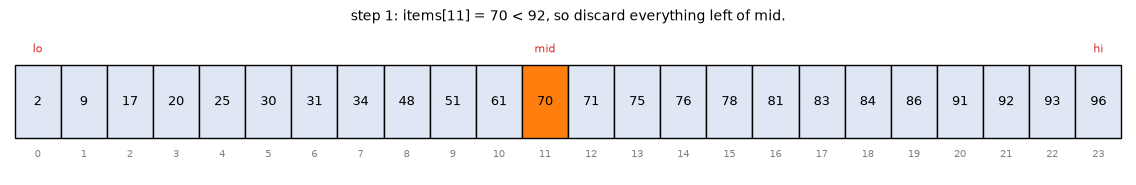

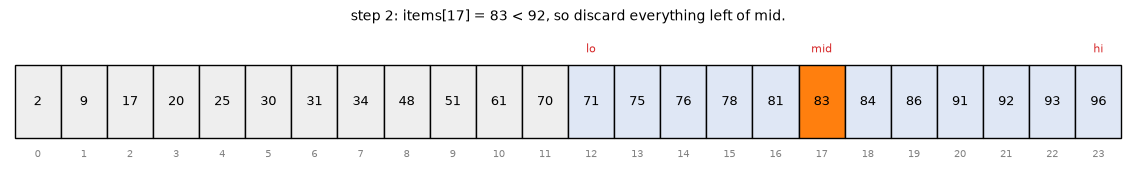

In [6]:
from dsalab import binary_search_stepper

binary_search_stepper()

## Try it yourself

**Exercise 1.** Give the Big-O class of each snippet. (a) `for x in a: total += x` (b) `for x in a: for y in a: pairs.append((x, y))` (c) `while n > 1: n = n // 2` (d) `a.sort(); return a[0]`

**Exercise 2.** Write `has_duplicate(a)` two ways: with two nested loops, and with a set. Time both with `growth_plot` on random lists.

**Exercise 3.** `sum(range(n))` is O(n). Write an O(1) version using the formula $n(n-1)/2$ and confirm with `time_it` that its time does not depend on n.

**Exercise 4 (challenge).** How many steps does this take? `i = 1; while i < n: i = i * 2`. What about `while i < n: i = i + 2`? Explain the difference in one sentence.

<details><summary>Solutions</summary>

```python
# Exercise 1: (a) O(n)  (b) O(n^2)  (c) O(log n)  (d) O(n log n), the sort dominates

# Exercise 2
def dup_nested(a):
    for i in range(len(a)):
        for j in range(i + 1, len(a)):
            if a[i] == a[j]:
                return True
    return False

def dup_set(a):
    seen = set()
    for x in a:
        if x in seen:
            return True
        seen.add(x)
    return False

random.seed(2)
growth_plot({"nested O(n^2)": lambda n: dup_nested(random.sample(range(10**9), n)),
             "set O(n)": lambda n: dup_set(random.sample(range(10**9), n))},
            {"nested O(n^2)": [200, 400, 800, 1600], "set O(n)": [10**3, 10**4, 10**5, 10**6]})

# Exercise 3
def sum_formula(n):
    return n * (n - 1) // 2
for n in [10**3, 10**6, 10**9]:
    print(n, f"{time_it(sum_formula, n) * 1e9:.0f} ns")

# Exercise 4: doubling reaches n in log2(n) steps, O(log n). Adding 2 takes n/2 steps, O(n).
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [7]:
from dsalab import quiz

quiz(1)

Checkpoint quiz, Module 1 (static preview). Run this cell in JupyterLab to answer interactively.

Q1. Big-O notation describes
    a) the exact running time in seconds
    b) how running time grows with input size, ignoring constants
    c) the memory a program uses
    d) how many lines of code an algorithm has

Q2. Binary search on one million sorted items needs at most about
    a) 1,000,000 comparisons
    b) 1,000 comparisons
    c) 20 comparisons
    d) 2 comparisons

Q3. For large inputs, which running time is best?
    a) O(n^2)
    b) O(n log n)
    c) O(n)
    d) O(log n)

Q4. Two nested loops that each run over all n items cost
    a) O(n)
    b) O(2n)
    c) O(n^2)
    d) O(n log n)


## Key takeaways

* Count steps as a function of n, then keep only the dominant term without its constant: that is the Big-O class.
* The classes in order: O(1), O(log n), O(n), O(n log n), O(n^2), O(2^n). Each step down is a different world at large n.
* Log-log timing plots turn classes into slopes. Measure whenever you can.
* Worst case is the default promise; average and amortised cost matter for hash tables, quicksort and dynamic arrays.

**Next:** the containers themselves, and what each one is cheap at. [Module 2](02_Arrays_Linked_Lists_Stacks_Queues.ipynb).

[Previous: Start Here](00_Start_Here.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 2: Arrays, Linked Lists, Stacks and Queues](02_Arrays_Linked_Lists_Stacks_Queues.ipynb)